# 06 - Forecasting Models

This notebook compares simple baselines and Random Forest models for one-month-ahead business review activity. The key comparison is whether SNA features improve prediction beyond historical review behavior and business metadata.

In [1]:
from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "new_orleans"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures" / "models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

FORECASTING_DATASET_PATH = PROCESSED_DIR / "forecasting_dataset.csv"
METRICS_OUTPUT_PATH = OUTPUTS_DIR / "forecasting_metrics.csv"
PREDICTIONS_OUTPUT_PATH = OUTPUTS_DIR / "forecasting_predictions.csv"

plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})
modeling = pd.read_csv(FORECASTING_DATASET_PATH)
print(modeling.shape)
modeling.head()

(95533, 28)


,business_id,monthly_review_count,monthly_star_sum,prev_month_reviews,rolling_3_avg,rolling_6_avg,same_month_previous_year,cumulative_review_count,cumulative_star_sum,avg_rating_history,...,avg_reviewer_degree,max_reviewer_pagerank,fraction_repeat_reviewers,reviewer_community_diversity,feature_month_str,target_month_str,calendar_month,month_sin,month_cos,feature_month_number
0,-1XSzguS6XLN-V6MVZMg2A,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,2015-01,2015-02,1,0.500000,8.660254e-01,1
1,-1XSzguS6XLN-V6MVZMg2A,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,2015-02,2015-03,2,0.866025,5.000000e-01,2
2,-1XSzguS6XLN-V6MVZMg2A,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,2015-03,2015-04,3,1.000000,6.123234e-17,3
3,-1XSzguS6XLN-V6MVZMg2A,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,2015-04,2015-05,4,0.866025,-5.000000e-01,4
4,-1XSzguS6XLN-V6MVZMg2A,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,2015-05,2015-06,5,0.500000,-8.660254e-01,5


In [2]:
def wape(y_true, y_pred):
    denominator = np.sum(np.abs(y_true))
    return np.nan if denominator == 0 else np.sum(np.abs(y_true - y_pred)) / denominator

def evaluate_predictions(split_name, model_name, y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    return {"split": split_name, "model": model_name, "rows": len(y_true), "MAE": mean_absolute_error(y_true, y_pred), "RMSE": mean_squared_error(y_true, y_pred) ** 0.5, "WAPE": wape(y_true, y_pred)}

splits = {
    "primary_covid_test": {"train_start": "2015-02", "train_end": "2019-12", "test_start": "2020-01", "test_end": "2021-12"},
    "secondary_pre_covid_test": {"train_start": "2015-02", "train_end": "2018-12", "test_start": "2019-01", "test_end": "2019-12"},
}

historical_features = ["prev_month_reviews", "rolling_3_avg", "rolling_6_avg", "same_month_previous_year", "cumulative_review_count", "avg_rating_history", "calendar_month", "month_sin", "month_cos", "feature_month_number"]
business_features = ["business_stars", "business_review_count", "is_restaurant", "is_food", "is_nightlife", "is_tourism"]
sna_features = ["recent_reviewer_count", "avg_reviewer_degree", "max_reviewer_pagerank", "fraction_repeat_reviewers", "reviewer_community_diversity"]
feature_sets = {
    "ML: historical": historical_features,
    "ML: historical + business": historical_features + business_features,
    "ML: historical + business + SNA": historical_features + business_features + sna_features,
}

In [3]:
metrics = []
prediction_frames = []
trained_models = {}

for split_name, split in splits.items():
    train_mask = (modeling["target_month_str"] >= split["train_start"]) & (modeling["target_month_str"] <= split["train_end"])
    test_mask = (modeling["target_month_str"] >= split["test_start"]) & (modeling["target_month_str"] <= split["test_end"])
    train_df = modeling[train_mask].copy()
    test_df = modeling[test_mask].copy()
    y_train = train_df["target_next_month_reviews"].astype(float)
    y_test = test_df["target_next_month_reviews"].astype(float)

    baseline_predictions = {
        "Baseline: last month": test_df["prev_month_reviews"].values,
        "Baseline: rolling 3-month avg": test_df["rolling_3_avg"].values,
        "Baseline: seasonal naive": test_df["same_month_previous_year"].values,
    }
    for model_name, y_pred in baseline_predictions.items():
        metrics.append(evaluate_predictions(split_name, model_name, y_test.values, y_pred))
        prediction_frames.append(test_df[["business_id", "feature_month_str", "target_month_str", "target_next_month_reviews"]].assign(split=split_name, model=model_name, prediction=np.clip(y_pred, 0, None)))

    for model_name, features in feature_sets.items():
        model = RandomForestRegressor(n_estimators=80, max_depth=12, min_samples_leaf=5, random_state=42, n_jobs=-1)
        model.fit(train_df[features], y_train)
        y_pred = model.predict(test_df[features])
        metrics.append(evaluate_predictions(split_name, model_name, y_test.values, y_pred))
        prediction_frames.append(test_df[["business_id", "feature_month_str", "target_month_str", "target_next_month_reviews"]].assign(split=split_name, model=model_name, prediction=np.clip(y_pred, 0, None)))
        trained_models[(split_name, model_name)] = (model, features)

metrics_df = pd.DataFrame(metrics).sort_values(["split", "WAPE", "MAE"])
predictions_df = pd.concat(prediction_frames, ignore_index=True)
metrics_df.to_csv(METRICS_OUTPUT_PATH, index=False)
predictions_df.to_csv(PREDICTIONS_OUTPUT_PATH, index=False)
metrics_df

,split,model,rows,MAE,RMSE,WAPE
0,primary_covid_test,Baseline: last month,27624,1.311323,2.653812,0.688473
1,primary_covid_test,Baseline: rolling 3-month avg,27624,1.342685,2.954533,0.704938
3,primary_covid_test,ML: historical,27624,1.445685,3.004346,0.759016
5,primary_covid_test,ML: historical + business + SNA,27624,1.473653,3.049569,0.773699
4,primary_covid_test,ML: historical + business,27624,1.479746,3.077057,0.776898
2,primary_covid_test,Baseline: seasonal naive,27624,2.877643,6.556732,1.510824
10,secondary_pre_covid_test,ML: historical + business,13812,1.833048,3.118196,0.383979
11,secondary_pre_covid_test,ML: historical + business + SNA,13812,1.836260,3.114596,0.384652
9,secondary_pre_covid_test,ML: historical,13812,1.889936,3.156896,0.395896
7,secondary_pre_covid_test,Baseline: rolling 3-month avg,13812,1.954798,3.306649,0.409483


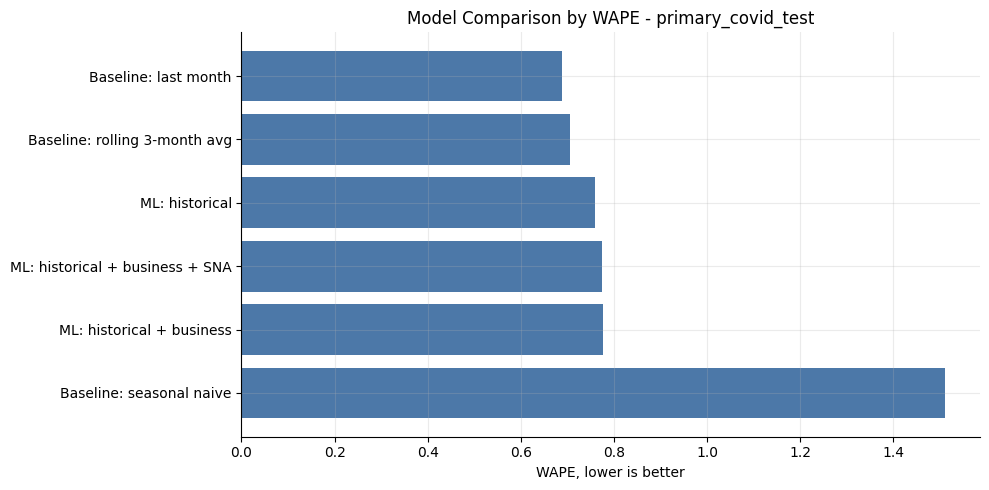

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\wape_comparison_primary_covid_test.png


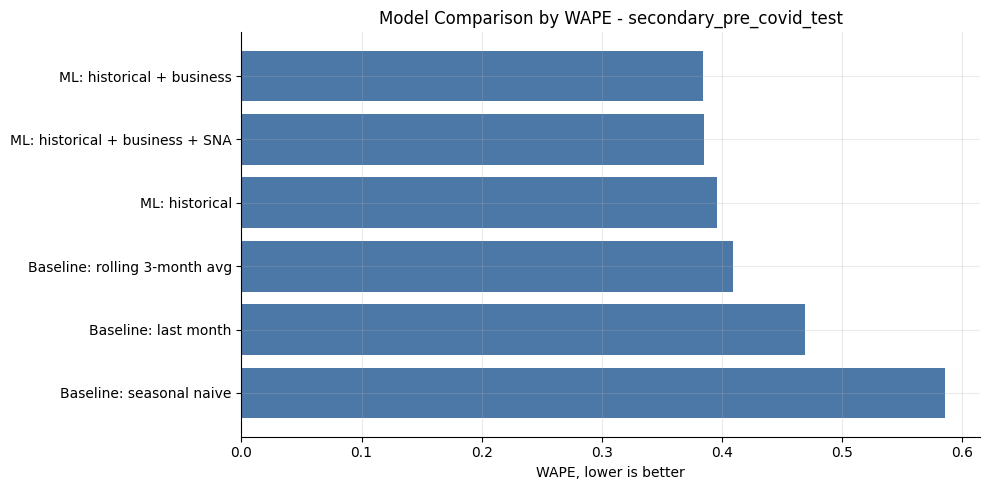

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\wape_comparison_secondary_pre_covid_test.png


In [4]:
for split_name in metrics_df["split"].unique():
    split_metrics = metrics_df[metrics_df["split"] == split_name].sort_values("WAPE")
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(split_metrics["model"], split_metrics["WAPE"], color="#4C78A8")
    ax.invert_yaxis()
    ax.set_title(f"Model Comparison by WAPE - {split_name}")
    ax.set_xlabel("WAPE, lower is better")
    fig.tight_layout()
    path = FIGURES_DIR / f"wape_comparison_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

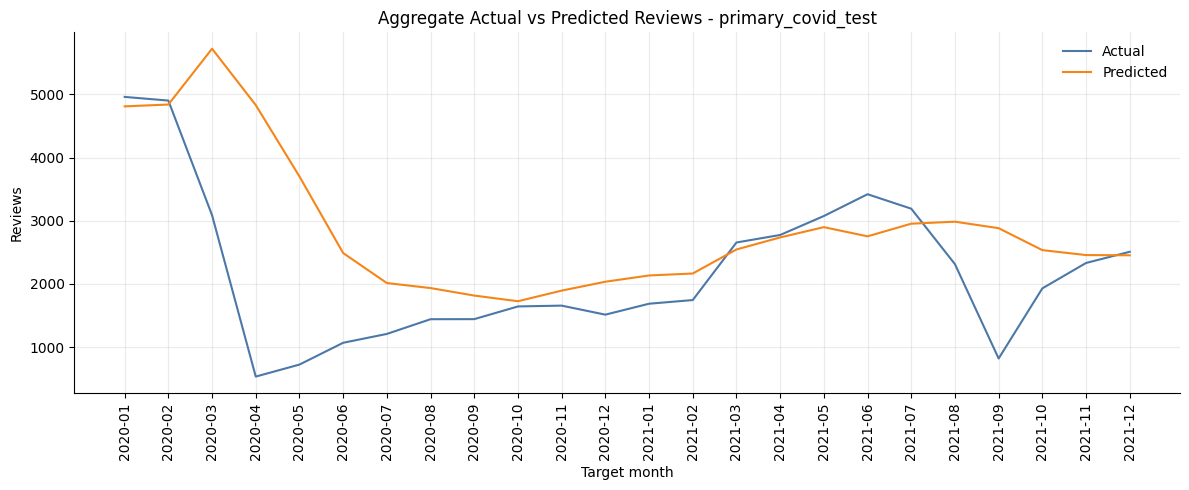

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\aggregate_actual_vs_predicted_primary_covid_test.png


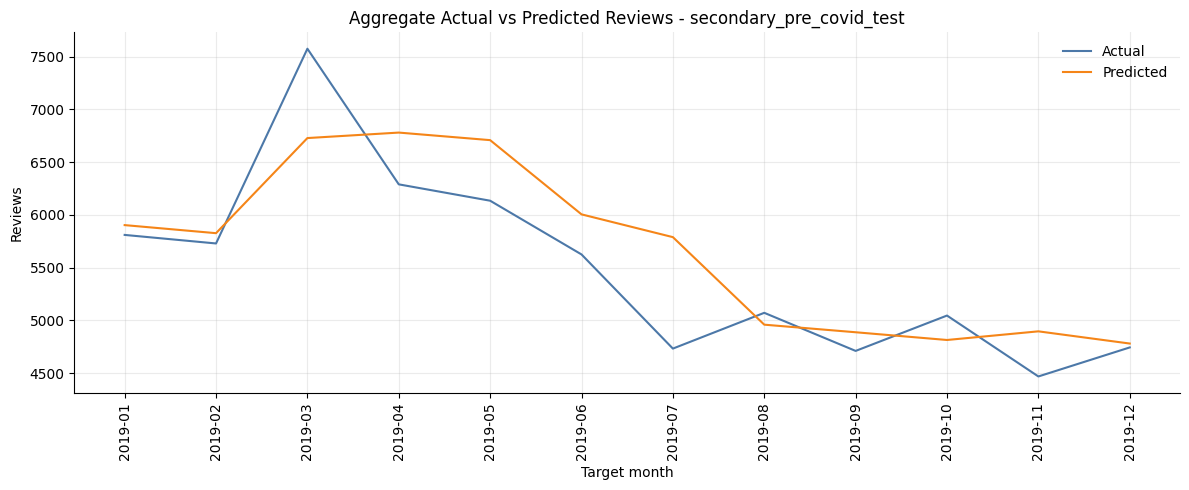

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\aggregate_actual_vs_predicted_secondary_pre_covid_test.png


In [5]:
comparison_model = "ML: historical + business + SNA"
for split_name in predictions_df["split"].unique():
    plot_df = predictions_df[(predictions_df["split"] == split_name) & (predictions_df["model"] == comparison_model)].copy()
    monthly = plot_df.groupby("target_month_str").agg(actual=("target_next_month_reviews", "sum"), predicted=("prediction", "sum")).reset_index()
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(monthly["target_month_str"], monthly["actual"], label="Actual", color="#4C78A8")
    ax.plot(monthly["target_month_str"], monthly["predicted"], label="Predicted", color="#F58518")
    ax.set_title(f"Aggregate Actual vs Predicted Reviews - {split_name}")
    ax.set_xlabel("Target month")
    ax.set_ylabel("Reviews")
    ax.tick_params(axis="x", rotation=90)
    ax.legend(frameon=False)
    fig.tight_layout()
    path = FIGURES_DIR / f"aggregate_actual_vs_predicted_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

In [6]:
importance_rows = []
for (split_name, model_name), (model, features) in trained_models.items():
    if model_name != "ML: historical + business + SNA":
        continue
    for feature, importance in zip(features, model.feature_importances_):
        importance_rows.append({"split": split_name, "feature": feature, "importance": importance})
importance_df = pd.DataFrame(importance_rows).sort_values(["split", "importance"], ascending=[True, False])
importance_df.head(20)

,split,feature,importance
1,primary_covid_test,rolling_3_avg,0.451517
16,primary_covid_test,recent_reviewer_count,0.407451
2,primary_covid_test,rolling_6_avg,0.046669
0,primary_covid_test,prev_month_reviews,0.028755
11,primary_covid_test,business_review_count,0.019067
4,primary_covid_test,cumulative_review_count,0.006980
7,primary_covid_test,month_sin,0.006096
9,primary_covid_test,feature_month_number,0.004653
19,primary_covid_test,fraction_repeat_reviewers,0.004457
8,primary_covid_test,month_cos,0.004358


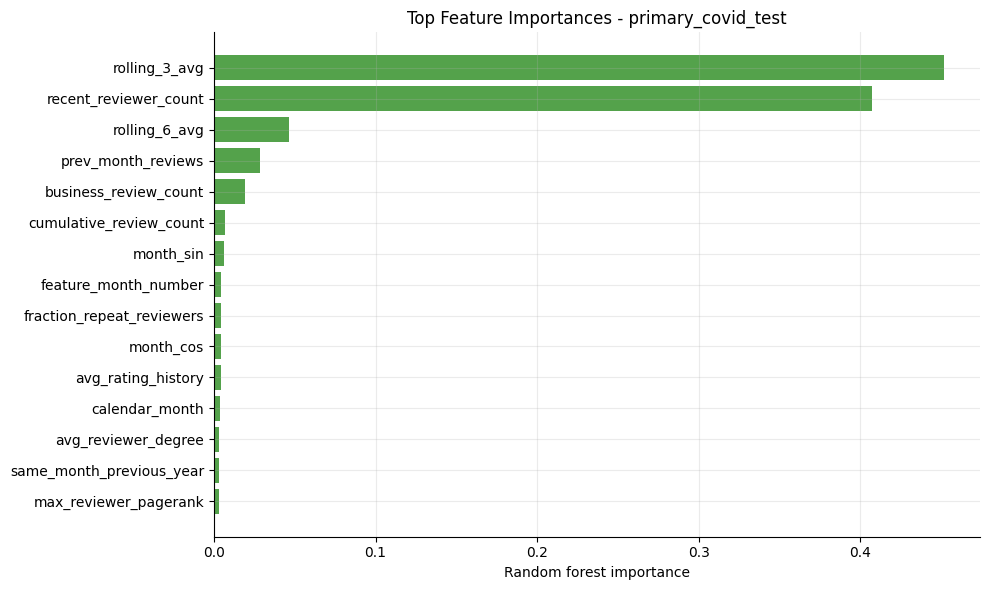

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\feature_importance_primary_covid_test.png


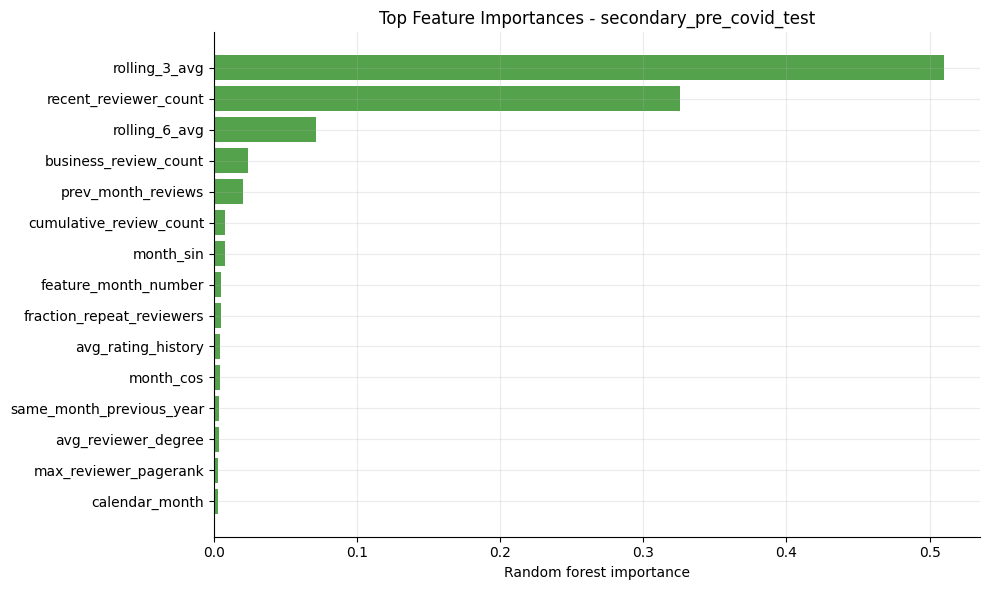

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\feature_importance_secondary_pre_covid_test.png


In [7]:
for split_name in importance_df["split"].unique():
    top_importance = importance_df[importance_df["split"] == split_name].head(15).sort_values("importance")
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_importance["feature"], top_importance["importance"], color="#54A24B")
    ax.set_title(f"Top Feature Importances - {split_name}")
    ax.set_xlabel("Random forest importance")
    fig.tight_layout()
    path = FIGURES_DIR / f"feature_importance_{split_name}.png"
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    print(path)

## Interpretation

The comparison is incremental: persistence baselines test how strong recent activity is, historical models add engineered time-series features, business models add static metadata, and the SNA model adds recent reviewer-network aggregates.

Current results are mixed. In the COVID-era split, the last-month baseline performs best, suggesting that the external shock limits the value of richer models. In the pre-COVID split, the historical + business model is best, while SNA adds little additional signal. This makes the negative or weak SNA result a valid finding rather than a failed pipeline.